In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

# torch.manual_seed(0)
# torch.cuda.manual_seed(0)

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

In [ ]:
dataset = "apex"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

# Y_init = F.pad(Y_init, pad=(14, 14, 14, 14), mode='reflect')

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

features: torch.Size([1024, 196])
tensor(1.1979, grad_fn=<MeanBackward0>)


9.83974

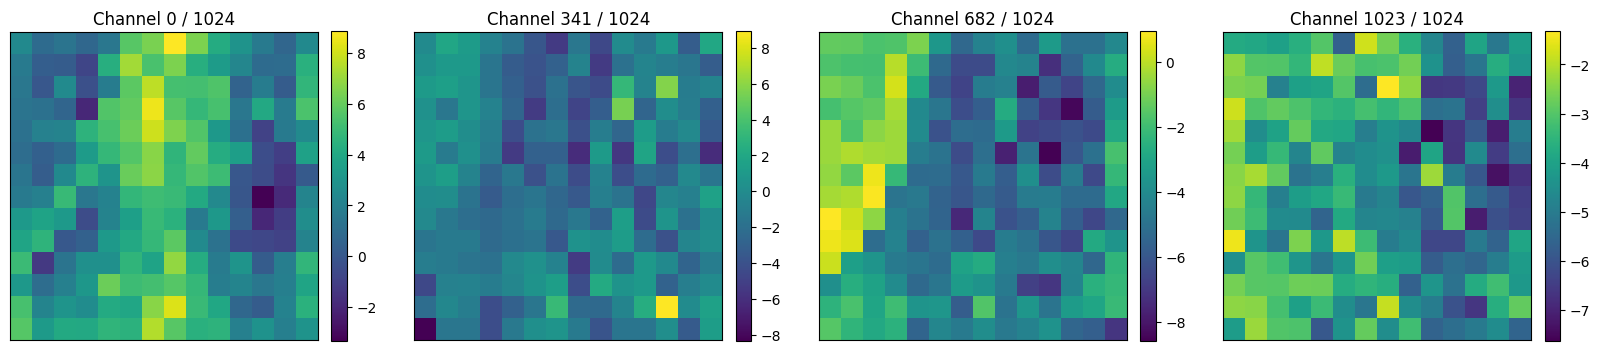

In [ ]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init_f, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

plots.plot_hsi(features.reshape(D, alpha, alpha), 4)
print(features.mean())

unmixer = unmx.UnmixingFromFeatures(D=D, H=new_H, alpha=alpha, B=B, c=c)
sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6

In [ ]:
def extract_4_features(fm, Y, new_H, alpha, D, wavelengths, A=None):
    Y_pad = F.pad(Y, pad=(alpha, alpha, alpha, alpha), mode='reflect')
    features_pad = torch.zeros(4*D, alpha**2)
    
    # Top left
    _, features = rsfm.extract_f(fm, Y_pad[:, :, :-alpha, :-alpha], new_H, wavelengths)
    features_pad[:D] = features
    
    # Top right
    _, features = rsfm.extract_f(fm, Y_pad[:, :, alpha:, :-alpha], new_H, wavelengths)
    features_pad[D:D*2] = features
    
    # Bottom left
    _, features = rsfm.extract_f(fm, Y_pad[:, :, alpha:, :-alpha], new_H, wavelengths)
    features_pad[D*2:D*3] = features
    
    # Bottom right
    _, features = rsfm.extract_f(fm, Y_pad[:, :, alpha:, alpha:], new_H, wavelengths)
    features_pad[D*3:D*4] = features
    
    if A != None:
        Y_fm, A_fm = rsfm.reshape_Y("DOFA", Y, A=A)
        return Y_fm, A_fm, features_pad
    else:
        Y_fm = rsfm.reshape_Y("DOFA", Y)
        return Y_fm, features_pad
    
def extract_9_features(fm, Y, new_H, alpha, D, wavelengths, A=None):
    Y_pad = F.pad(Y, pad=(alpha, alpha, alpha, alpha), mode='reflect')
    features_pad = torch.zeros(9*D, alpha**2)

    for i in range(3):
        for j in range(3):
            _, features = rsfm.extract_f(fm, Y_pad[:, :, alpha*i:alpha*i+new_H, alpha*j:alpha*j+new_H], new_H, wavelengths)
            features_pad[D*(i+3*j):D*(i+3*j+1)] = features
    
    if A != None:
        Y_fm, A_fm = rsfm.reshape_Y("DOFA", Y, A=A)
        return Y_fm, A_fm, features_pad
    else:
        Y_fm = rsfm.reshape_Y("DOFA", Y)
        return Y_fm, features_pad   

def reshape_tensor(tensor, D):
    C, _, _ = tensor.shape

    if D < C:
        # Randomly select D bands from C
        indices = torch.randperm(C)[:D]
        return tensor[indices, :, :]
    elif D > C:
        # Repeat the C bands to match D
        repeat_times = D // C
        remainder = D % C
        repeated = tensor.repeat(repeat_times, 1, 1)
        if remainder > 0:
            extra = tensor[:remainder, :, :]
            return torch.cat([repeated, extra], dim=0)
        return repeated
    else:
        return tensor

In [ ]:
# downsample = nn.AdaptiveAvgPool2d((alpha, alpha))
# Y_down = downsample(Y_init)
# Y_down_D = reshape_tensor(Y_down[0], D)
# plots.plot_hsi(Y_down)
# plots.plot_hsi(Y_down_D)

training 0/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.084, NMSE = 0.142
training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.086, NMSE = 0.148
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.186, NMSE = 0.110
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.090, NMSE = 0.141
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.476, NMSE = 0.152
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.091, NMSE = 0.146
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.087, NMSE = 0.143

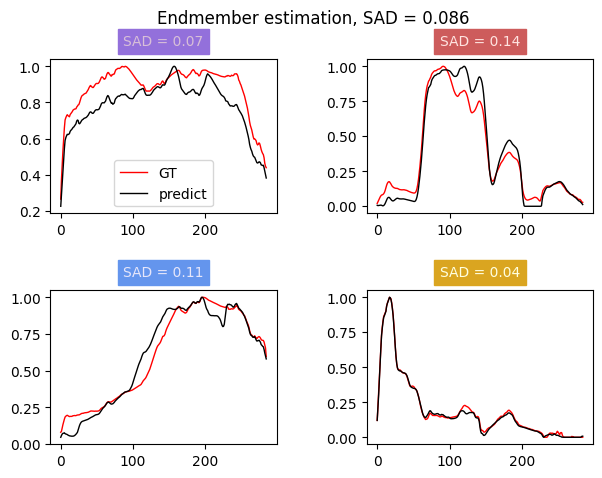

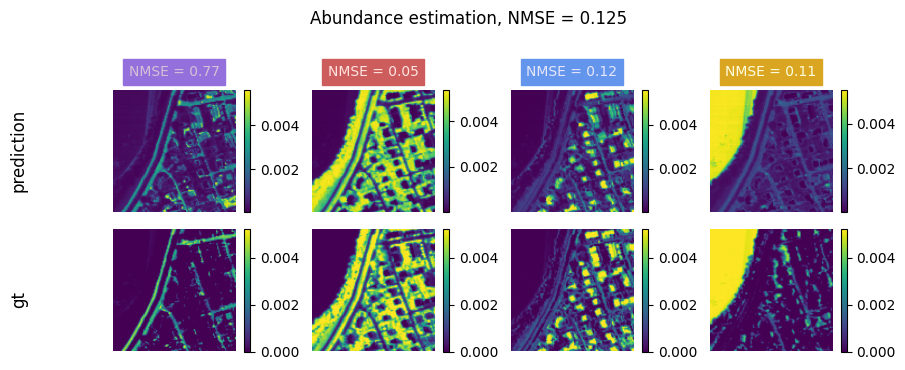

In [ ]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp): 
    print(f"training {i}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, upsampler="FiLM grouped")
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y_pad = F.pad(Y, pad=(14, 14, 14, 14), mode='reflect')

            Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            # features = reshape_tensor(downsample(Y_fm[0]), D).flatten(1)
            # Y_fm, features = extract_4_features(fm, Y, new_H, alpha, D, wavelengths)
            E_hat, A_hat, Y_hat = model(features, Y_fm)

            # Y_fm = F.interpolate(Y, size=(new_H, new_H))
            # features = utils.oneD_to_2d(features)[:, 1:-1, 1:-1].flatten(1)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
        # features = reshape_tensor(downsample(Y_fm[0]), D).flatten(1)
        # _, A_init_fm, features = extract_4_features(fm, Y, new_H, alpha, D, wavelengths, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)

        # features = utils.oneD_to_2d(features)[:, 1:-1, 1:-1].flatten(1)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

training 0/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.179, NMSE = 0.180
training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.246, NMSE = 0.210
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.143, NMSE = 0.211
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.155, NMSE = 0.189
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.136, NMSE = 0.201
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.245, NMSE = 0.379
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.155, NMSE = 0.215

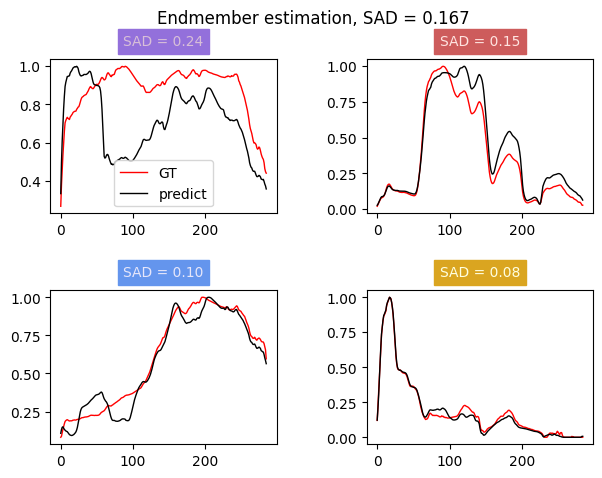

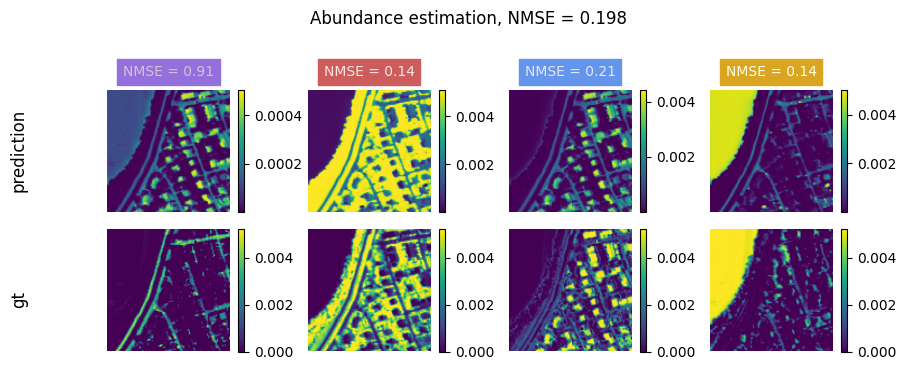

In [ ]:
# """Linear upsampling of abundances"""

# n_xp = 10
# mses, sads = [], []
# E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# for i in range(n_xp): 
#     print(f"training {i}/{n_xp}")

#     model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#     epochs, lr = 200, 0.002
#     optim_wrapper = dict(
#         optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#         constructor='LayerDecayOptimizerConstructor_ViT',
#         paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
#     optimizer = build_optim_wrapper(model, optim_wrapper)

#     flag = False
    
#     for _ in range(epochs):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)
#             # Y_pad = F.pad(Y, pad=(14, 14, 14, 14), mode='reflect')

#             Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#             # Y_fm, features = extract_4_features(fm, Y, new_H, alpha, D, wavelengths)
            
#             # Y_fm = F.interpolate(Y, size=(new_H, new_H))
#             # features = utils.oneD_to_2d(features)
#             # features = features[:, 1:-1, 1:-1]
#             # features = features.flatten(1)

#             E_hat, A_hat, Y_hat, A_hat_lr = model(features, Y_fm)
#             Y_hat_lr = model.decoder(A_hat_lr)
#             if E_hat.isnan().any():
#                 flag=True
#                 print("nan")
#                 break

#             loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
    
#     if not flag:
#         model.eval()
        
#         with torch.no_grad():
#             _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
#             # Y_fm, A_init_fm, features = extract_4_features(fm, Y, new_H, alpha, D, wavelengths, A_init)

#             # features = utils.oneD_to_2d(features)[:, 1:-1, 1:-1].flatten(1)
            
#             E_hat, A_hat, _, A_hat_lr = model(features, Y_fm)
#             if E_hat.isnan().any():
#                 print("Nans during test")
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
#             print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#             mses.append(mse)
#             sads.append(sad)

#         E_hats[i] = E_hat
#         A_hats[i] = A_hat.squeeze(0)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
# print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


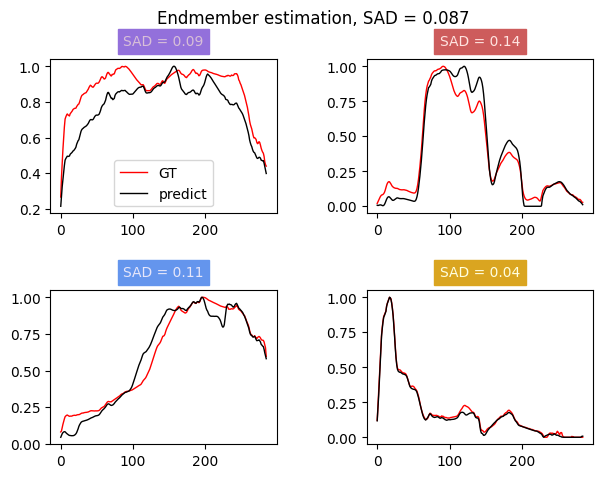

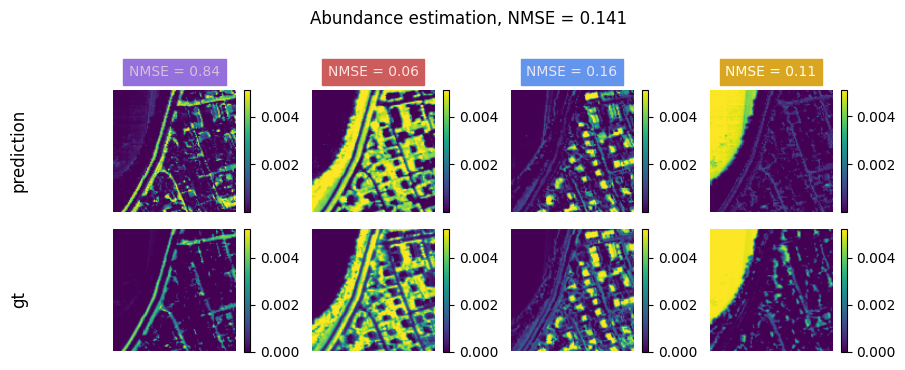

In [ ]:
"""Linear upsampling of abundances from learned E_hat"""

loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
model.apply(model.weights_init)
state_dict = model.decoder.state_dict()
state_dict["decoder.weight"][:,:,0,0] = E_hat_m
model.decoder.load_state_dict(state_dict)
for param in model.decoder.parameters():
    param.requires_grad = False

epochs, lr = 200, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
optimizer = build_optim_wrapper(model, optim_wrapper)

for _ in range(epochs):

    for Y, _, _ in loader:
    
        optimizer.zero_grad()

        Y = utils.oneD_to_2d(Y).to(dev)

        Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

        E_hat, A_hat, Y_hat, A_hat_lr = model(features)
        Y_hat_lr = model.decoder(A_hat_lr)

        loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
            
model.eval()

with torch.no_grad():
    _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
    E_hat, A_hat, _, A_hat_lr = model(features)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
    # print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")

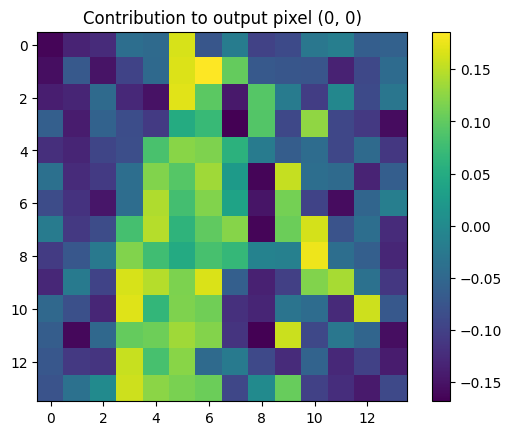

In [ ]:
# W = model.upsample.weight
# W = W.reshape(int(W.shape[0]**0.5), int(W.shape[0]**0.5), int(W.shape[1]**0.5), int(W.shape[1]**0.5))
# i, j = 0, 0  # Example: top-left output pixel
# plt.imshow(W[i, j].detach().cpu(), cmap="viridis")
# plt.title(f"Contribution to output pixel ({i}, {j})")
# plt.colorbar()
# plt.show()

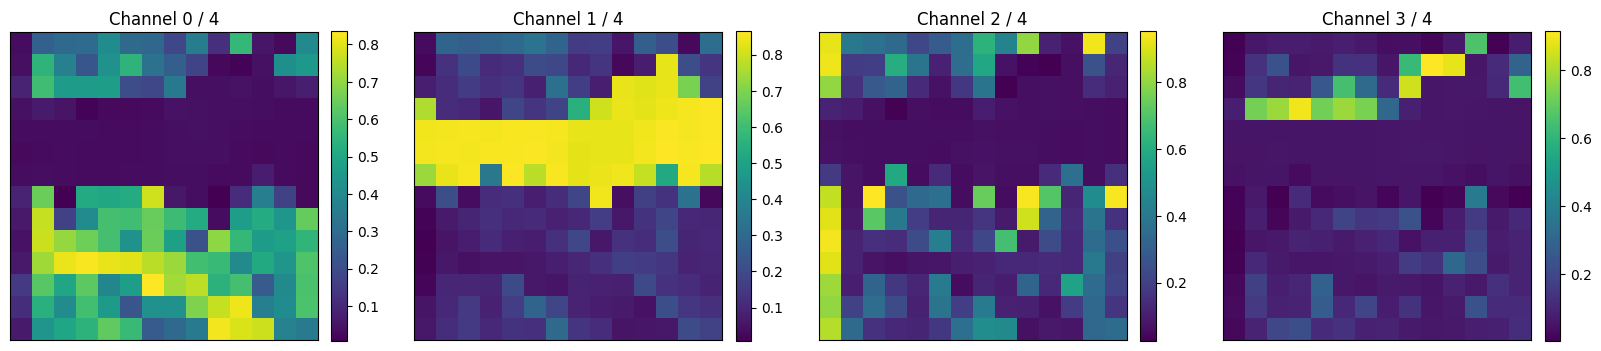

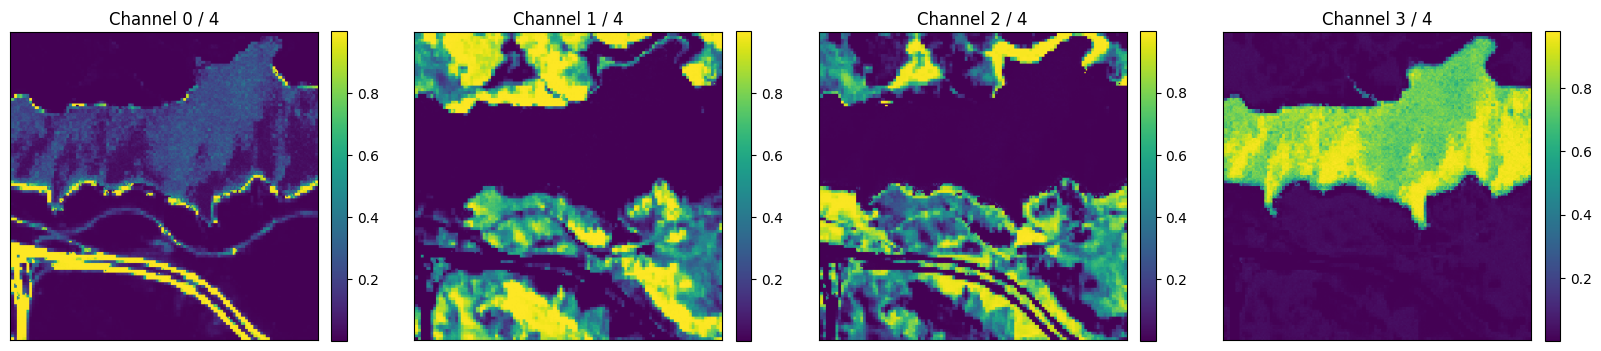

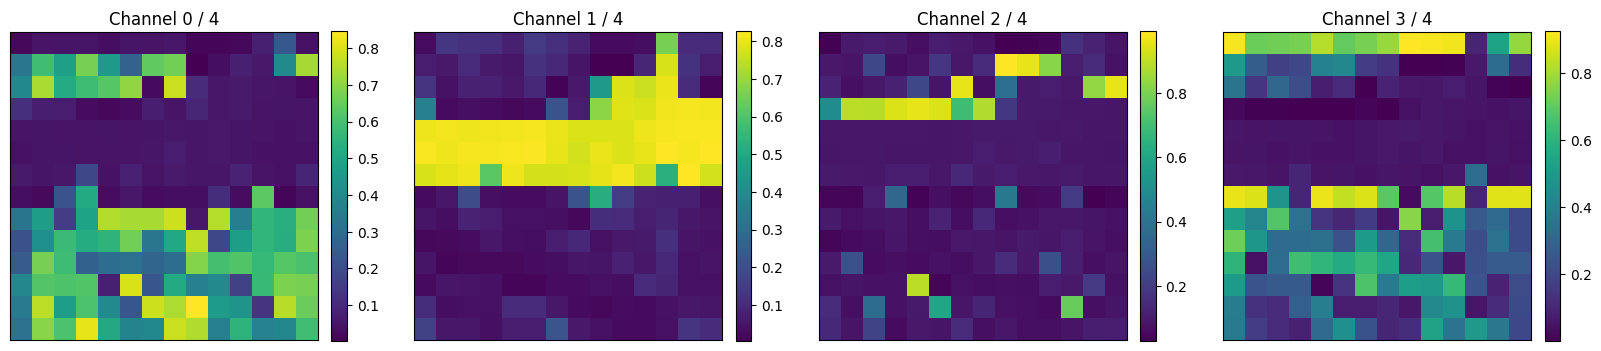

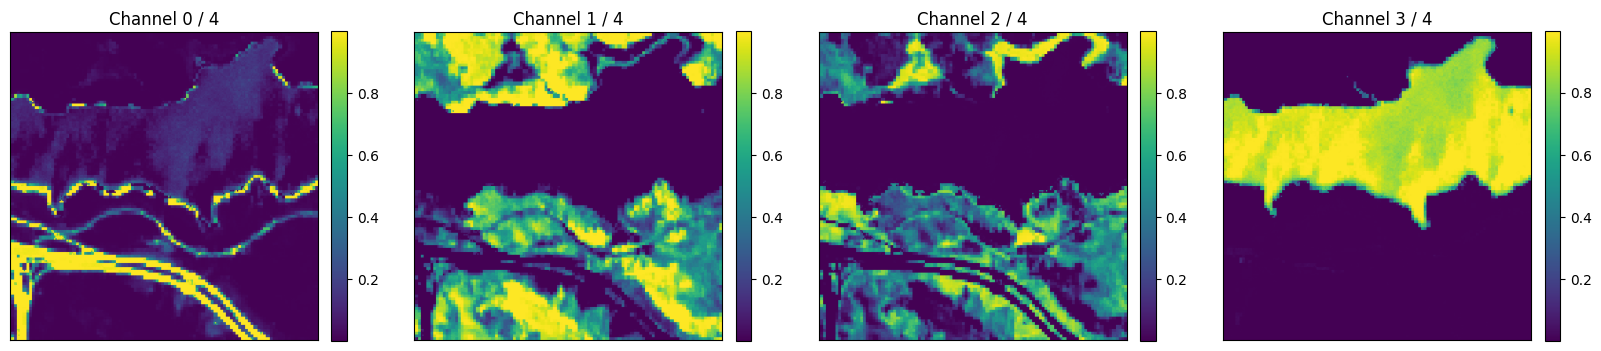

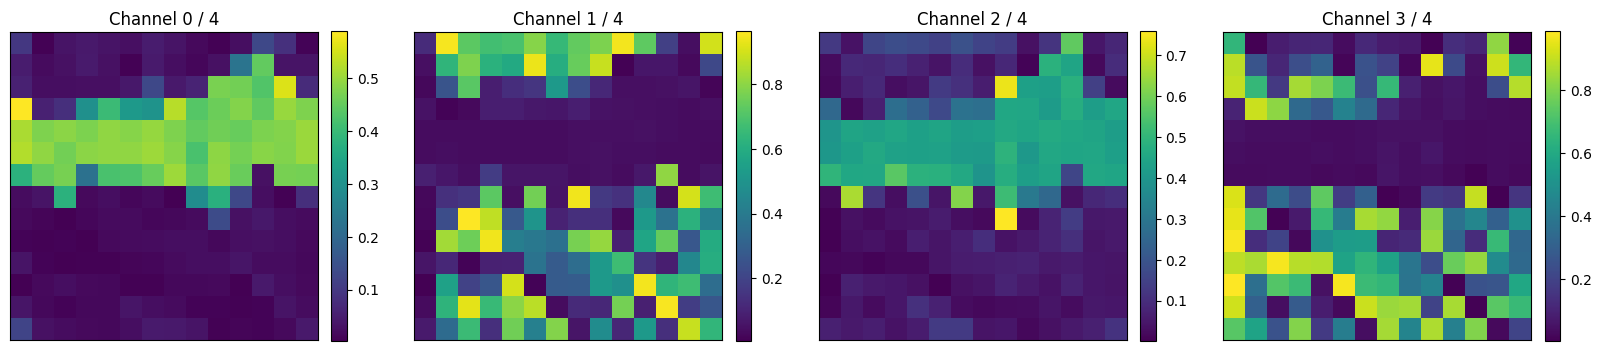

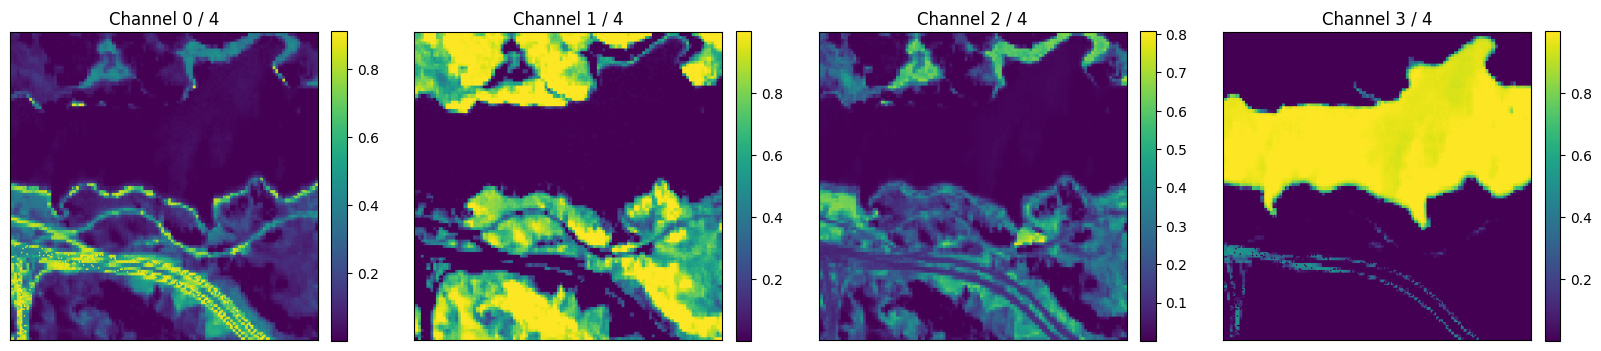

In [ ]:
for i in range(n_xp):
    plots.plot_hsi(lr_abundances[i])
    plots.plot_hsi(upsampled_abundances[i])

In [ ]:
mse_loss = nn.MSELoss()

E_hat_2, A_hat_m_2, _ = utils.order_endmembers(E_init, E_hat_m, A_hat_m)
rmse = torch.sqrt(mse_loss(A_init, A_hat_m_2))
rmse

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([3, 95, 95])) that is different to the input size (torch.Size([1, 3, 95, 95])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


tensor(0.1635, device='cuda:0')